In [1]:
import numpy as np
import scipy.stats as sts

In [2]:
def BIC_AIC(datos, distribucion, parametros, k=None):
    n=len(datos)

    if k is None:
        k = len(parametros)

    log_verosimilitud=np.sum(distribucion.logpdf(datos, *parametros))
    AIC=-2*log_verosimilitud+2*k
    BIC=-2*log_verosimilitud+k*np.log(n)
    return AIC, BIC

In [3]:
def ajuste(datos, distribuciones):
    mejor_distribucion=None
    mejor_parametros=None
    mejor_BIC=np.inf
    
    for distribucion in distribuciones:
        parametros=distribucion.fit(datos)
        AIC, BIC=BIC_AIC(datos, distribucion, parametros)
        
        if BIC < mejor_BIC:
            mejor_distribucion=distribucion
            mejor_parametros=parametros
            mejor_BIC=BIC
    return mejor_distribucion, mejor_parametros, mejor_BIC

In [4]:
import seaborn as sns

diam=sns.load_dataset('diamonds')

In [5]:
diam.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
diam_premium=diam[diam['cut']=='Premium']

In [7]:
diam_premium.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
12,0.22,Premium,F,SI1,60.4,61.0,342,3.88,3.84,2.33
14,0.20,Premium,E,SI2,60.2,62.0,345,3.79,3.75,2.27
15,0.32,Premium,E,I1,60.9,58.0,345,4.38,4.42,2.68


In [8]:
premium_depth=diam_premium['depth']

In [9]:
from scipy.stats import norm, chi2, lognorm, gamma

distribuciones1=[norm, chi2, lognorm, gamma]
ajuste(premium_depth, distribuciones1)

(<scipy.stats._continuous_distns.norm_gen at 0x1b46731ecc0>,
 (np.float64(61.26467261257343), np.float64(1.158772879427068)),
 np.float64(43220.75333775202))

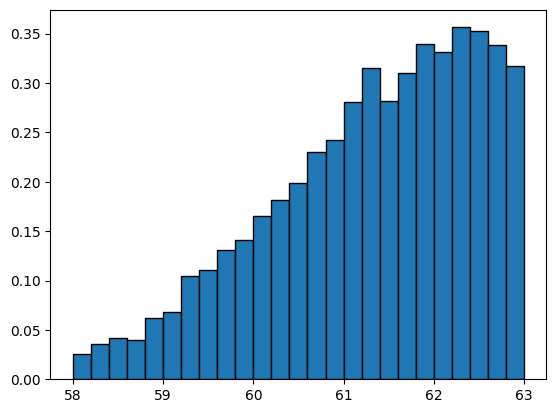

In [11]:
import matplotlib.pyplot as plt

plt.hist(premium_depth, density=True, bins=25, edgecolor='black')
plt.show()
# una normal truncada, no terminad de bajar

In [11]:
premium_depth.describe()

count    13791.000000
mean        61.264673
std          1.158815
min         58.000000
25%         60.500000
50%         61.400000
75%         62.200000
max         63.000000
Name: depth, dtype: float64

In [13]:
#M2: Normal Truncada

from scipy.stats import truncnorm
from scipy.optimize import minimize
import numpy as np

x=premium_depth.to_numpy()

L=58
U=63

def menos_logverosimilitud(parametros):
    mu, sigma = parametros
    
    a=(L-mu)/sigma
    b=(U-mu)/sigma
    
    return -np.sum(truncnorm.logpdf(x, a, b, loc=mu, scale=sigma))

# resultado=minimize(menos_logverosimilitud, x0=[x.mean(), x.std()], method='Nelder-Mead')
resultado=minimize(menos_logverosimilitud, x0=[x.mean(), x.std()])
resultado

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 19803.55219322318
        x: [ 6.216e+01  1.810e+00]
      nit: 11
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 2.644e-03  1.527e-03]
            [ 1.527e-03  1.128e-03]]
     nfev: 48
     njev: 16

In [15]:
mu, sigma=resultado.x
a=(58-mu)/sigma
b=(63-mu)/sigma
M2=truncnorm(a, b, loc=mu, scale=sigma)
logL=np.sum(M2.logpdf(x))
-2*logL + 2*np.log(len(x))

np.float64(39626.16792941531)

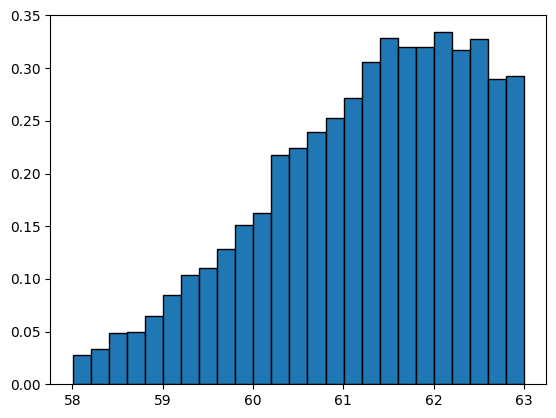

In [16]:
dataM2=M2.rvs(size=10000)
plt.hist(dataM2, density=True, bins =25, edgecolor='black')
plt.show()

In [15]:
#M3: Beta Re-escalada
from scipy.stats import beta

alpha, betta, loc, scale=beta.fit(x)
alpha, betta, loc, scale

(2.283754005896782, 1.1262256966503974, 57.73855966431543, 5.269192731951263)

In [16]:
M3=beta(alpha, betta, loc=loc, scale=scale)
L3=np.sum(M3.logpdf(x))
-2*L3+4*np.log(len(x))

39911.3138722565

In [17]:
from scipy.stats import weibull_min

c, loc, scale = weibull_min.fit(x)

In [19]:
MW=weibull_min(c, loc=loc, scale=scale)
L4=np.sum(MW.logpdf(x))
-2*L4+4*np.log(len(x))

np.float64(41663.62681320432)

densidad de la t
fda(t) | 58<=t<=63 / F_T(63) - F_T(58)   <- empirica? 